<a href="https://colab.research.google.com/github/BUFONJOKER/100days-deeplearning-course-campusx/blob/main/CNN/23_dog_vs_cat_cnn_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional Neural Networks (CNNs) using Cat vs Dog Dataset in TensorFlow/Keras

## Importing Libraries

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"
import keras
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import kagglehub

## Loading the Dataset

In [2]:
path = kagglehub.dataset_download("salader/dogsvscats")

Using Colab cache for faster access to the 'dogsvscats' dataset.


In [3]:
os.listdir(path)

['test', 'train', 'catsvsdogs']

In [4]:
path

'/kaggle/input/dogsvscats'

In [5]:
train_dir = os.path.join(path, 'train')
test_dir = os.path.join(path, 'test')

train_data = keras.utils.image_dataset_from_directory(
    directory=train_dir, labels="inferred", label_mode='int',batch_size=32,
    image_size=(256, 256)
)

test_data = keras.utils.image_dataset_from_directory(
    directory=test_dir, labels="inferred", label_mode='int',batch_size=32,
    image_size=(256, 256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


## Normalizing Data

In [6]:
def process(image, label):
    image = tf.cast(image/255., tf.float32)
    return image, label

In [7]:
train_data = train_data.map(process)
test_data = test_data.map(process)

In [8]:
train_data.element_spec[0].shape

TensorShape([None, 256, 256, 3])

In [9]:
train_data.element_spec

(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None),
 TensorSpec(shape=(None,), dtype=tf.int32, name=None))

In [10]:
train_data

<_MapDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

## Viewing Sample Images

### View Train Dataset Samples

In [11]:
# taking random 1 image
def train_data_plot_image():
    for images, labels in train_data.take(1):
        image = images[0].numpy()
        label = labels[0].numpy()

        plt.imshow(image)
        plt.title(f"Train data 1 for Dog, 0 for Cat\n Label = {label}")
        plt.axis("off")
        plt.show()

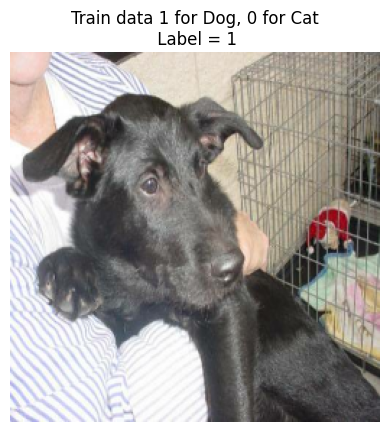

In [12]:
train_data_plot_image()

### Viewing Test Dataset Random Samples

In [13]:
# taking random 1 image
def test_data_plot_image():
    for images, labels in test_data.take(1):
        image = images[0].numpy()
        label = labels[0].numpy()

        plt.imshow(image)
        plt.title(f"Test data 1 for Dog, 0 for Cat\n Label = {label}")
        plt.axis("off")
        plt.show()

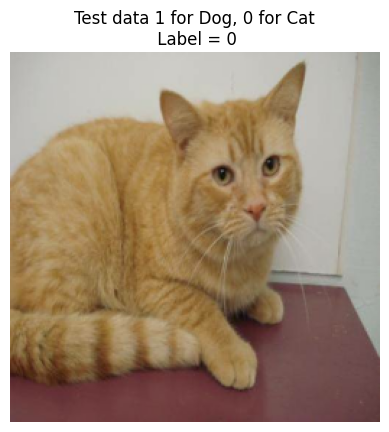

In [14]:
test_data_plot_image()

## CNN Models

### Model 1

In [15]:
model_1 = keras.Sequential(
    [
        keras.layers.Input(shape=(256,256,3)),

        keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='valid'),
        keras.layers.MaxPooling2D(strides=2),

        keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='valid'),
        keras.layers.MaxPooling2D(strides=2),

        keras.layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='valid'),
        keras.layers.MaxPooling2D(strides=2),

        keras.layers.Flatten(),

        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(32, activation='relu'),

        keras.layers.Dense(1, activation='sigmoid')
    ]
)

In [16]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,849,345 (56.65 MB)

 Trainable params: 14,849,345 (56.65 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model_1.compile(loss=keras.losses.BinaryCrossentropy(), optimizer=keras.optimizers.Adam(), metrics=['accuracy'])

In [ ]:
history_1 = model_1.fit(train_data, epochs=10, validation_data=test_data)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 91s 128ms/step - accuracy: 0.6112 - loss: 0.6490 - val_accuracy: 0.7518 - val_loss: 0.5055
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 64s 103ms/step - accuracy: 0.7648 - loss: 0.4880 - val_accuracy: 0.7858 - val_loss: 0.4429
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.8261 - loss: 0.3884 - val_accuracy: 0.7900 - val_loss: 0.5277
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 84ms/step - accuracy: 0.8939 - loss: 0.2542 - val_accuracy: 0.7784 - val_loss: 0.7157
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - accuracy: 0.9540 - loss: 0.1197 - val_accuracy: 0.7696 - val_loss: 0.8060
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.9720 - loss: 0.0770 - val_accuracy: 0.7876 - val_loss: 0.9564
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 88s 99ms/step - accuracy: 0.9798 - loss: 0.0617 - val_accuracy: 0.7886 - val_loss: 1.1044
Epoch 8/10
566/625 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.9823 - loss: 0.0519

In [ ]:
plt.plot(history_1.history['loss'], label='Training Loss')
plt.plot(history_1.history['val_loss'], label='Validation Loss')
plt.title("Loss over Epochs")
plt.legend()
plt.show()

In [ ]:
plt.plot(history_1.history['accuracy'], label='Training Accuracy')
plt.plot(history_1.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy over Epochs")
plt.legend()
plt.show()

### Model 2

In [ ]:
model_2 = keras.Sequential(
    [
        keras.layers.Input(shape=(256,256,3)),

        keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='valid'),
        keras.layers.MaxPooling2D(strides=2),

        keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='valid'),
        keras.layers.MaxPooling2D(strides=2),

        keras.layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='valid'),
        keras.layers.MaxPooling2D(strides=2),

        keras.layers.Flatten(),

        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(32, activation='relu'),

        keras.layers.Dense(1, activation='sigmoid')
    ]
)

In [ ]:
model_2.summary()

In [ ]:
model_2.compile(loss=keras.losses.BinaryCrossentropy(), optimizer=keras.optimizers.Adam(), metrics=['accuracy'])

In [ ]:
history_2 = model_2.fit(train_data, epochs=10, validation_data=test_data)

In [ ]:
plt.plot(history_2.history['loss'], label='Training Loss')
plt.plot(history_2.history['val_loss'], label='Validation Loss')
plt.title("Loss over Epochs")
plt.legend()
plt.show()

In [ ]:
plt.plot(history_2.history['accuracy'], label='Training Accuracy')
plt.plot(history_2.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy over Epochs")
plt.legend()
plt.show()